# Donut Fine-Tuned Model Test — `AutoModel` 버전

`naver-clova-ix/donut-base-finetuned-cord-v2` 모델로 CORD-v2(영수증 파싱)를 테스트합니다.

이 노트북은 `donut_CORD_v2_fine_tunned_pipeline_test.ipynb` 의 **`pipeline`** 호출을
**`AutoProcessor` + `AutoModelForImageTextToText`** 직접 로드 + `model.generate()` 방식으로
바꾼 버전입니다. 출력 JSON은 동일하며, 생성 과정을 명시적으로 제어합니다.

> **🔹 역할** — Python/PyTorch/CUDA 환경 및 GPU 정보 출력

In [1]:
import sys, torch
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.10.19 (main, Oct 21 2025, 16:38:01) [GCC 11.2.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10


> **🔹 역할** — 필요 라이브러리(AutoProcessor/AutoModelForImageTextToText, datasets 등) import

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

from datasets import load_dataset
import torch, json, re
import matplotlib.pyplot as plt

## `pipeline` vs `AutoModel`

세 노트북은 **같은 모델 · 같은 결과**를 추상화 수준만 다르게 호출합니다.

| | `..._test.ipynb` | `..._pipeline_test.ipynb` | **이 노트북 (AutoModel)** |
|---|---|---|---|
| 모델 로드 | `VisionEncoderDecoderModel` (구체 클래스) | `pipeline(...)` | `AutoModelForImageTextToText` (Auto 클래스) |
| 프로세서 | `DonutProcessor` | pipeline 내부 | `AutoProcessor` |
| 전처리/생성/후처리 | 전부 수동 | 전부 자동 | 전처리·생성 수동, token2json 내장 |
| 제어 수준 | 높음 | 낮음 | **높음 (Auto API로)** |

- `AutoModelForImageTextToText.from_pretrained(...)` 는 모델 config의 `model_type`
  (`vision-encoder-decoder`)을 보고 알맞은 구체 클래스(`VisionEncoderDecoderModel`)를
  **자동 선택**합니다. 모델 종류를 바꿔도 같은 코드가 동작하는 게 Auto 클래스의 장점입니다.
- `pipeline` 과 달리 `model.generate(...)` 를 직접 호출하므로 빔 서치, 길이, 금지 토큰 등
  생성 옵션을 세밀하게 조정할 수 있습니다.

## Base Model vs Fine-tuned Model

### Base Model (`donut-base`)
대량의 문서 이미지로 **일반적인 패턴**을 학습한 모델 — IIT-CDIP(영문 스캔 문서 약 1,100만 장)로
"이미지의 텍스트를 읽는 능력" 자체를 익힘. 특정 태스크는 아직 모름.

### Fine-tuned Model (`donut-base-finetuned-cord-v2`)
Base를 출발점으로 CORD-v2(영수증 800장 + 정답 JSON)로 추가 학습 → 영수증을 `gt_parse`
JSON 구조로 변환하는 태스크에 특화.

```
Base Model   = 대학 졸업생  (읽기·이해력은 갖춤, 전문 업무는 아직 모름)
Fine-tuning  = 입사 후 실무 교육  (영수증 처리 업무만 집중 훈련)
Fine-tuned   = 영수증 처리 전문 직원  (영수증 → JSON 즉시 변환 가능)
```

## 모델 / 프로세서 로드 (AutoModel)

`AutoProcessor` 와 `AutoModelForImageTextToText` 로 로드합니다. 둘 다 모델 이름만 주면
내부적으로 `DonutProcessor` / `VisionEncoderDecoderModel` 로 해석됩니다.

> **🔹 역할** — AutoProcessor/AutoModel로 CORD-v2 파인튜닝 모델 자동 로드 후 GPU·추론 모드 설정

In [3]:
model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"

# AutoProcessor: 이미지 전처리 + 토크나이저 (→ DonutProcessor 로 해석됨)
processor = AutoProcessor.from_pretrained(model_name)

# AutoModelForImageTextToText: config(model_type=vision-encoder-decoder)를 보고
# VisionEncoderDecoderModel 을 자동 선택해 로드
model = AutoModelForImageTextToText.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()   # 추론 모드: dropout off, gradient 불필요
print(f"processor: {type(processor).__name__} | model: {type(model).__name__} | device: {device}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


processor: DonutProcessor | model: VisionEncoderDecoderModel | device: cuda


## CORD-v2 Dataset 구조

영수증 이미지 + JSON 어노테이션으로 구성된 문서 파싱 벤치마크.

| Split | train | validation | test |
|---|---|---|---|
| 샘플 수 | 800 | 100 | 100 |

| 컬럼 | 타입 | 설명 |
|---|---|---|
| `image` | PIL Image | 영수증 이미지 |
| `ground_truth` | JSON string | 레이블 + 메타 정보 전체 |

```
ground_truth
├── gt_parse              ← Donut 학습에 사용하는 핵심 레이블
│   ├── menu []           ← 주문 항목 (nm, cnt, price, unitprice ...)
│   ├── sub_total         ← 소계 (subtotal_price, tax_price ...)
│   └── total             ← 합계 (total_price, cashprice ...)
└── valid_line []         ← 단어별 바운딩 박스 (OCR 전용, Donut 미사용)
```

> **🔹 역할** — CORD-v2 테스트셋 첫 샘플 로드 후 이미지·정답(gt_parse) 표시

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 1
})
샘플 수: 1, 컬럼 수: 2

=== 이미지 정보 ===
크기: (432, 648)  모드: RGB

=== gt_parse 내용 ===
{
  "menu": {
    "nm": "-TICKET CP",
    "num": "901016",
    "cnt": "2",
    "price": "60.000",
    "itemsubtotal": "60.000"
  },
  "sub_total": {
    "subtotal_price": "60.000",
    "discount_price": "-60.000",
    "tax_price": "5.455"
  },
  "total": {
    "total_price": "60.000",
    "creditcardprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


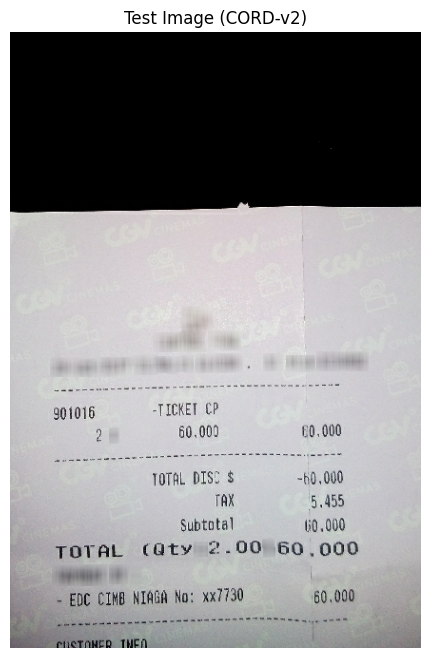

In [4]:
# CORD-v2 테스트셋 첫 번째 샘플 1장만 로드
dataset = load_dataset("naver-clova-ix/cord-v2", split="test[:1]")
print(dataset)
print(f"샘플 수: {len(dataset)}, 컬럼 수: {len(dataset.features)}")

image = dataset[0]["image"]
ground_truth = json.loads(dataset[0]["ground_truth"])

print("\n=== 이미지 정보 ===")
print(f"크기: {image.size}  모드: {image.mode}")

print("\n=== gt_parse 내용 ===")
print(json.dumps(ground_truth["gt_parse"], indent=2, ensure_ascii=False))

plt.figure(figsize=(6, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Test Image (CORD-v2)")
plt.show()

## 추론 (Inference) — `model.generate()` 직접 호출

pipeline이 내부에서 처리하던 단계를 명시적으로 수행합니다.

1. **태스크 토큰 → `decoder_input_ids`** : `<s_cord-v2>` 를 디코더 시작 입력으로.
2. **이미지 → `pixel_values`** : `processor` 가 1280×960 리사이즈 + 정규화.
3. **`model.generate(...)`** : 토큰 시퀀스 생성 (UNK 금지, EOS에서 중단, KV-cache 사용).
4. **특수토큰 제거** : EOS/PAD 제거 후 맨 앞 태스크 토큰을 정규식으로 제거.

> **🔹 역할** — 태스크 토큰으로 model.generate 추론을 수행해 원시 출력 시퀀스 생성·정제

In [5]:
task_prompt = "<s_cord-v2>"

# 1) 태스크 토큰 → decoder 시작 입력
decoder_input_ids = processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

# 2) 이미지 → pixel_values (1280×960 리사이즈 + [-1,1] 정규화)
pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

# 3) 생성
with torch.no_grad():
    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=model.config.decoder.max_position_embeddings,  # 768
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,            # EOS 도달 시 중단
        use_cache=True,                                            # KV-cache 로 가속
        bad_words_ids=[[processor.tokenizer.unk_token_id]],       # UNK 생성 금지
        return_dict_in_generate=True,
    )

# 4) 디코딩 + 특수토큰/태스크토큰 제거
sequence = processor.batch_decode(outputs.sequences)[0]
sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(
    processor.tokenizer.pad_token, ""
)
sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()   # 맨 앞 <s_cord-v2> 제거
print("Raw output:", sequence)

Raw output: <s_menu><s_nm> - TICKET CP</s_nm><s_num> 901016</s_num><s_unitprice> 60.000</s_unitprice><s_cnt> 2</s_cnt><s_price> 60,000</s_price></s_menu><s_sub_total><s_subtotal_price> -60.000</s_subtotal_price><s_tax_price> 5,455</s_tax_price></s_sub_total><s_total><s_total_price> 60.000</s_total_price><s_emoneyprice> 60.000</s_emoneyprice><s_menuqty_cnt> 2.00</s_menuqty_cnt></s_total>


### 토큰 시퀀스 → JSON

`DonutProcessor` 내장 `token2json` 으로 `<s_key>값</s_key>` 패턴을 재귀 파싱해 dict로 변환합니다.

> **🔹 역할** — 프로세서 내장 token2json으로 출력 토큰을 dict로 파싱

In [6]:
result = processor.token2json(sequence)

print("Parsed result:")
print(json.dumps(result, indent=2, ensure_ascii=False))

Parsed result:
{
  "menu": {
    "nm": "- TICKET CP",
    "num": "901016",
    "unitprice": "60.000",
    "cnt": "2",
    "price": "60,000"
  },
  "sub_total": {
    "subtotal_price": "-60.000",
    "tax_price": "5,455"
  },
  "total": {
    "total_price": "60.000",
    "emoneyprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


> **🔹 역할** — 데이터셋 정답(gt_parse)과 모델 예측 결과 비교 출력

In [7]:
# 데이터셋 정답(gt_parse)과 모델 예측 비교
print("=== Ground Truth (gt_parse) ===")
print(json.dumps(ground_truth["gt_parse"], indent=2, ensure_ascii=False))
print("\n=== Prediction ===")
print(json.dumps(result, indent=2, ensure_ascii=False))

=== Ground Truth (gt_parse) ===
{
  "menu": {
    "nm": "-TICKET CP",
    "num": "901016",
    "cnt": "2",
    "price": "60.000",
    "itemsubtotal": "60.000"
  },
  "sub_total": {
    "subtotal_price": "60.000",
    "discount_price": "-60.000",
    "tax_price": "5.455"
  },
  "total": {
    "total_price": "60.000",
    "creditcardprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}

=== Prediction ===
{
  "menu": {
    "nm": "- TICKET CP",
    "num": "901016",
    "unitprice": "60.000",
    "cnt": "2",
    "price": "60,000"
  },
  "sub_total": {
    "subtotal_price": "-60.000",
    "tax_price": "5,455"
  },
  "total": {
    "total_price": "60.000",
    "emoneyprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


> **🔹 역할** — 입력 이미지와 파싱 결과(JSON)를 나란히 시각화

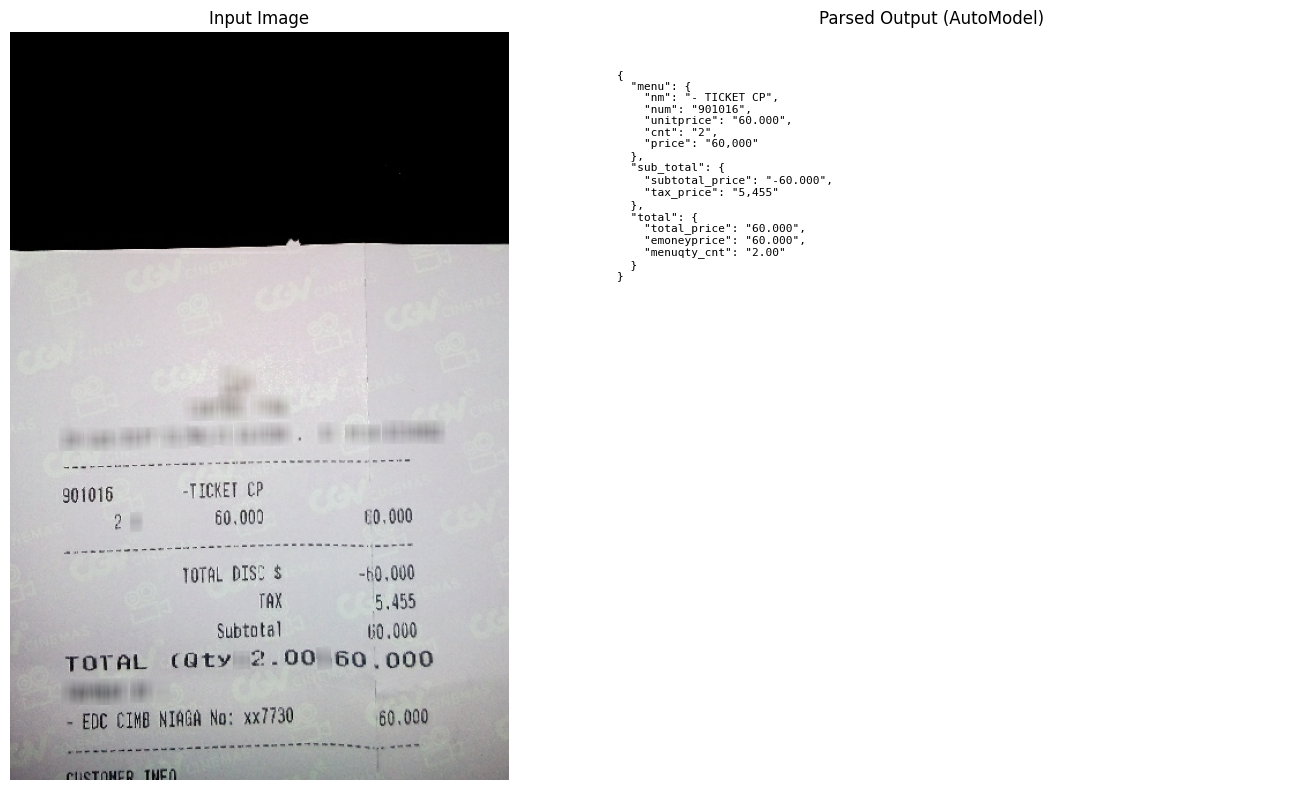

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title("Input Image")

axes[1].axis("off")
axes[1].set_title("Parsed Output (AutoModel)")
axes[1].text(
    0.05, 0.95,
    json.dumps(result, indent=2, ensure_ascii=False),
    transform=axes[1].transAxes,
    fontsize=8,
    verticalalignment="top",
    fontfamily="monospace",
)

plt.tight_layout()
plt.show()